## Importation of data and libraries


In [4]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/sentiment/sentiment - IMDb Movie Review Sentiment/train.csv")

# Display first few rows
df.head()


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


## Check basic data infromation


In [5]:
# Basic info
df.info()

# Check for missing values
df.isnull().sum()

# Count sentiment labels
df['label'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    25000 non-null  object
 1   label   25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB


label
0    12500
1    12500
Name: count, dtype: int64

## Visualize Sentiments

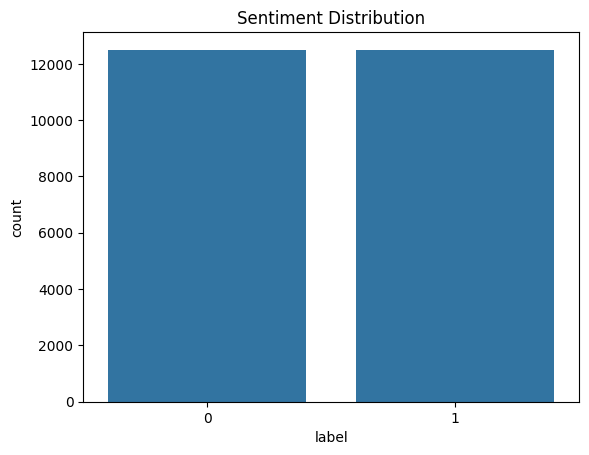

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='label')
plt.title("Sentiment Distribution")
plt.show()


## Word cloud review


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Positive review text length: 16556493
Negative review text length: 15983234


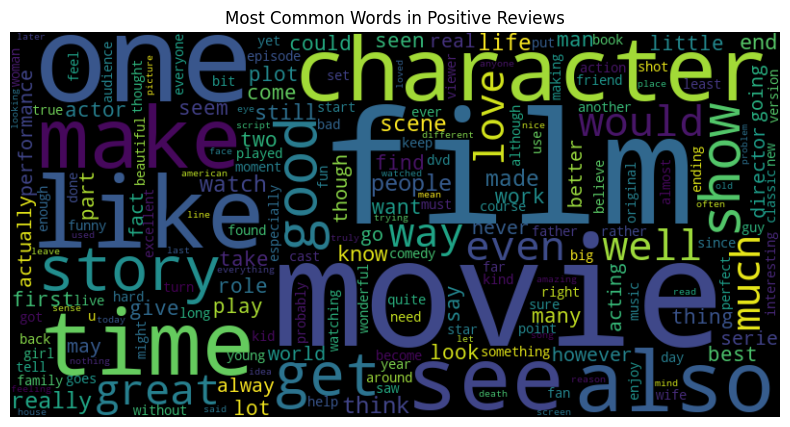

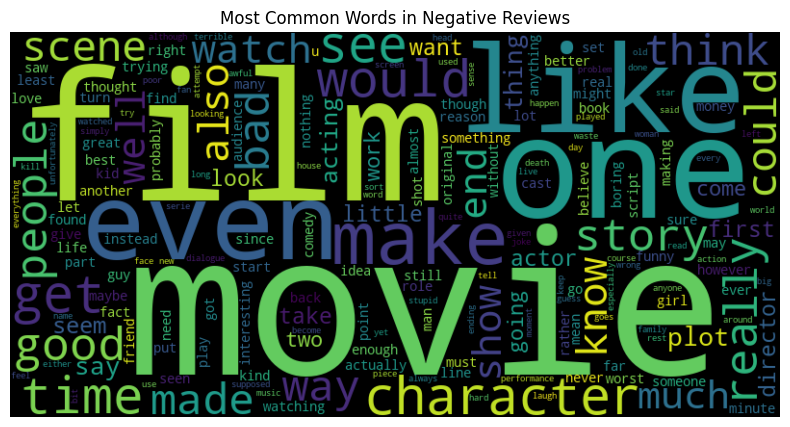

In [14]:
from wordcloud import WordCloud
import nltk
import re
import matplotlib.pyplot as plt

# Download stopwords
nltk.download('stopwords')
from nltk.corpus import stopwords
stopwords_set = set(stopwords.words("english"))

# Clean function
def clean_text(text):
    text = re.sub(r'<.*?>', '', str(text))  # Remove HTML tags
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # Keep only letters
    text = text.lower()
    return text

# Drop missing reviews just in case
df = df.dropna(subset=['text'])

# Combine and clean all positive and negative reviews
pos_text = " ".join(clean_text(review) for review in df[df.label == 1 ]['text'])
neg_text = " ".join(clean_text(review) for review in df[df.label == 0 ]['text'])

# Check lengths (sanity check)
print("Positive review text length:", len(pos_text))
print("Negative review text length:", len(neg_text))

# WordCloud for Positive Reviews
wc = WordCloud(width=800, height=400, stopwords=stopwords_set).generate(pos_text)
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Most Common Words in Positive Reviews")
plt.show()

# WordCloud for Negative Reviews
wc = WordCloud(width=800, height=400, stopwords=stopwords_set).generate(neg_text)
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Most Common Words in Negative Reviews")
plt.show()


## Save cleaned data

In [16]:
df['clean_review'] = df['text'].apply(clean_text)
df.to_csv("../data/sentiment/sentiment - IMDb Movie Review Sentiment cleaned.csv", index=False)
